# Задание №4. Классификация ЭЭГ по вейвлет-изображениям

**Файл данных:** `chb08_05.edf`  
**Цель:** сформировать 100 изображений ЭЭГ: 50 с приступом и 50 без приступа, разложить их по отдельным папкам, обучить CNN и сохранить модель.

В официальной разметке CHB-MIT для `chb08_05.edf` указан один приступ: **2856–3046 с**.  
В этом ноутбуке фрагменты с приступом берутся внутри этого интервала, а фрагменты без приступа — из безопасных интервалов вне приступа.


In [1]:
# При необходимости установите пакеты:
# !pip install mne scipy scikit-learn torch matplotlib pillow pandas

from pathlib import Path
import json
import random
import shutil

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn

torch.set_num_threads(1)
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)


In [2]:
# Пути проекта
EDF_PATH = Path("chb08_05.edf")
if not EDF_PATH.exists():
    # путь для запуска внутри среды ChatGPT /mnt/data
    EDF_PATH = Path("/mnt/data/chb08_05.edf")

PROJECT_DIR = Path("chb08_05_solution")
DATASET_DIR = PROJECT_DIR / "dataset_wavelet"
SEIZURE_DIR = DATASET_DIR / "seizure"
NON_SEIZURE_DIR = DATASET_DIR / "non_seizure"
FIG_DIR = PROJECT_DIR / "figures"
MODEL_DIR = PROJECT_DIR / "models"
META_DIR = PROJECT_DIR / "metadata"

for p in [SEIZURE_DIR, NON_SEIZURE_DIR, FIG_DIR, MODEL_DIR, META_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("EDF:", EDF_PATH)
print("Папка изображений с приступом:", SEIZURE_DIR)
print("Папка изображений без приступа:", NON_SEIZURE_DIR)


EDF: chb08_05.edf
Папка изображений с приступом: chb08_05_solution\dataset_wavelet\seizure
Папка изображений без приступа: chb08_05_solution\dataset_wavelet\non_seizure


In [3]:
# Чтение EDF
raw = mne.io.read_raw_edf(str(EDF_PATH), preload=True, verbose="ERROR")
sfreq = float(raw.info["sfreq"])
duration = raw.n_times / sfreq
n_channels = len(raw.ch_names)

# Разметка приступа для chb08_05.edf
SEIZURE_START = 2856.0
SEIZURE_END = 3046.0

# Используем один биполярный канал для построения скалограмм
CHANNEL = "FT9-FT10" if "FT9-FT10" in raw.ch_names else raw.ch_names[0]

print("Частота дискретизации:", sfreq)
print("Длительность записи, с:", duration)
print("Число каналов:", n_channels)
print("Использованный канал:", CHANNEL)
print("Интервал приступа:", SEIZURE_START, "-", SEIZURE_END, "с")


Частота дискретизации: 256.0
Длительность записи, с: 3600.0
Число каналов: 23
Использованный канал: FT9-FT10
Интервал приступа: 2856.0 - 3046.0 с


In [4]:
# Предобработка сигнала: выбор канала, перевод в микровольты, фильтрация 0.5-40 Гц, z-нормализация
signal_uv = raw.get_data(picks=[CHANNEL])[0] * 1e6
sos = signal.butter(4, [0.5, 40], btype="bandpass", fs=sfreq, output="sos")
signal_f = signal.sosfiltfilt(sos, signal_uv)
signal_f = (signal_f - np.mean(signal_f)) / (np.std(signal_f) + 1e-12)

SEGMENT_DURATION = 3.0
N_PER_CLASS = 50
IMAGE_SIZE = (96, 96)

# 50 окон с приступом внутри 2856-3046 с
seizure_starts = np.linspace(SEIZURE_START, SEIZURE_END - SEGMENT_DURATION, N_PER_CLASS)

# 50 окон без приступа вне интервала приступа
non_starts = np.concatenate([
    np.linspace(60, 2400, 25),
    np.linspace(3180, 3570, 25)
])

print("Количество окон с приступом:", len(seizure_starts))
print("Количество окон без приступа:", len(non_starts))


Количество окон с приступом: 50
Количество окон без приступа: 50


In [5]:
# Функции извлечения фрагмента и построения вейвлет-изображения

freqs = np.linspace(1, 40, 48)

def extract_segment(sig, start_s, dur_s, fs):
    i0 = int(round(start_s * fs))
    n = int(round(dur_s * fs))
    seg = sig[i0:i0+n].copy()
    if len(seg) < n:
        seg = np.pad(seg, (0, n-len(seg)), mode="edge")
    return (seg - seg.mean()) / (seg.std() + 1e-8)

def cwt_morlet_power(x, fs, freqs, w0=6.0):
    """Простая реализация CWT с комплексным Morlet-вейвлетом."""
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    out = np.empty((len(freqs), n), dtype=np.float32)
    for idx, f in enumerate(freqs):
        s = w0 * fs / (2 * np.pi * f)
        half_len = int(np.ceil(3.5 * s))
        t = np.arange(-half_len, half_len + 1) / fs
        sigma_t = s / fs
        wavelet = (np.pi ** -0.25) * np.exp(2j * np.pi * f * t) * np.exp(-(t ** 2) / (2 * sigma_t ** 2))
        wavelet = wavelet / np.sqrt(np.sum(np.abs(wavelet)**2) + 1e-12)
        conv = signal.fftconvolve(x, np.conj(wavelet[::-1]), mode="same")
        out[idx] = (np.abs(conv) ** 2).astype(np.float32)
    return out


## Дополнительные графики из отчёта

Следующие две ячейки строят именно те два рисунка, которые вставлены в Word-отчёт: разметку файла `chb08_05.edf` с выбранными 3-секундными окнами и пример двух фрагментов ЭЭГ для классов `non_seizure` и `seizure`.


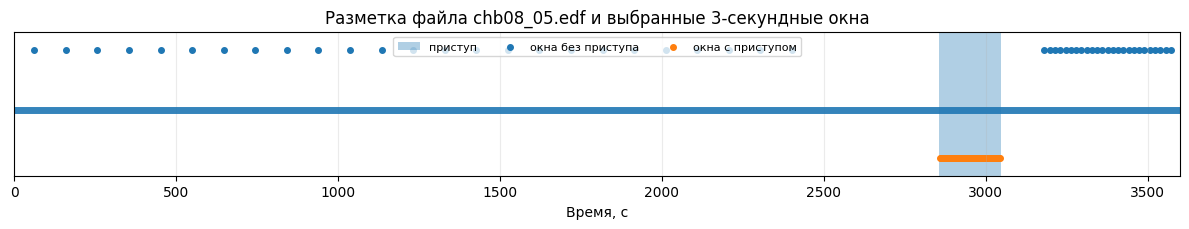

In [6]:
# Рисунок 1. Разметка файла chb08_05.edf и выбранные 3-секундные окна
# Голубая область показывает интервал приступа 2856-3046 с.
# Синие точки — центры окон без приступа, оранжевые точки — центры окон с приступом.

fig, ax = plt.subplots(figsize=(12, 2.4))

# Интервал приступа по официальной разметке CHB-MIT
ax.axvspan(SEIZURE_START, SEIZURE_END, alpha=0.35, label="приступ")

# Визуальная ось всей EDF-записи
ax.hlines(y=0.45, xmin=0, xmax=duration, linewidth=5, alpha=0.9)

# Центры выбранных 3-секундных окон
non_centers = non_starts + SEGMENT_DURATION / 2
seizure_centers = seizure_starts + SEGMENT_DURATION / 2

ax.scatter(non_centers, np.full_like(non_centers, 0.95), s=16, label="окна без приступа")
ax.scatter(seizure_centers, np.full_like(seizure_centers, 0.05), s=16, label="окна с приступом")

ax.set_title("Разметка файла chb08_05.edf и выбранные 3-секундные окна")
ax.set_xlabel("Время, с")
ax.set_xlim(0, duration)
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([])
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="upper center", ncol=3, fontsize=8)
plt.tight_layout()

# Сохранение рисунка в папку figures для отчёта
plt.savefig(FIG_DIR / "seizure_timeline.png", dpi=160)
plt.show()

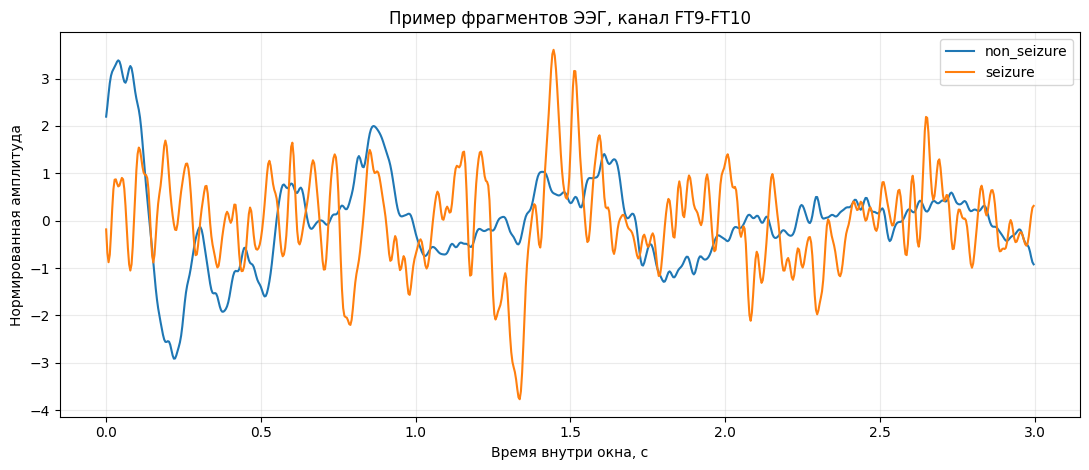

In [7]:
# Рисунок 2. Пример 3-секундных фрагментов ЭЭГ для двух классов
# Берём один фрагмент из области без приступа и один фрагмент из области приступа.

example_non_start = float(non_starts[0])
example_seizure_start = float(seizure_starts[0])

example_non = extract_segment(signal_f, example_non_start, SEGMENT_DURATION, sfreq)
example_seizure = extract_segment(signal_f, example_seizure_start, SEGMENT_DURATION, sfreq)

time_axis = np.arange(len(example_non)) / sfreq

plt.figure(figsize=(11, 4.8))
plt.plot(time_axis, example_non, label="non_seizure")
plt.plot(time_axis, example_seizure, label="seizure")
plt.title(f"Пример фрагментов ЭЭГ, канал {CHANNEL}")
plt.xlabel("Время внутри окна, с")
plt.ylabel("Нормированная амплитуда")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

# Сохранение рисунка в папку figures для отчёта
plt.savefig(FIG_DIR / "signal_examples.png", dpi=160)
plt.show()

In [8]:
# Формирование 100 вейвлет-изображений и разложение по папкам seizure / non_seizure
# Если папки уже существуют, очищаем только PNG, чтобы результат был воспроизводимым.
for folder in [SEIZURE_DIR, NON_SEIZURE_DIR]:
    for old in folder.glob("*.png"):
        old.unlink()

items = []
for label, starts in [("seizure", seizure_starts), ("non_seizure", non_starts)]:
    for i, st in enumerate(starts, 1):
        seg = extract_segment(signal_f, st, SEGMENT_DURATION, sfreq)
        power = np.log1p(cwt_morlet_power(seg, sfreq, freqs))[::-1, :]
        fname = f"{label}_{i:03d}_{st:.1f}s.png"
        items.append({
            "file": fname,
            "label": label,
            "class_id": int(label == "seizure"),
            "start_s": float(st),
            "end_s": float(st + SEGMENT_DURATION),
            "power": power
        })

# Глобальная нормализация сохраняет различия мощности между окнами
all_values = np.concatenate([it["power"].ravel() for it in items])
p01, p99 = np.percentile(all_values, [1, 99])
cmap = plt.get_cmap("viridis")

rows = []
for it in items:
    img_norm = np.clip((it["power"] - p01) / (p99 - p01 + 1e-12), 0, 1)
    rgb = (cmap(img_norm)[:, :, :3] * 255).astype(np.uint8)
    img = Image.fromarray(rgb).resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
    out_dir = SEIZURE_DIR if it["label"] == "seizure" else NON_SEIZURE_DIR
    img.save(out_dir / it["file"])
    rows.append({k: it[k] for k in ["file", "label", "class_id", "start_s", "end_s"]})

segments_df = pd.DataFrame(rows)
segments_df["channel"] = CHANNEL
segments_df["segment_duration_s"] = SEGMENT_DURATION
segments_df["sfreq_hz"] = sfreq
segments_df.to_csv(META_DIR / "segments.csv", index=False, encoding="utf-8")

print("seizure:", len(list(SEIZURE_DIR.glob("*.png"))))
print("non_seizure:", len(list(NON_SEIZURE_DIR.glob("*.png"))))
print("total:", len(list(DATASET_DIR.glob("*/*.png"))))


seizure: 50
non_seizure: 50
total: 100


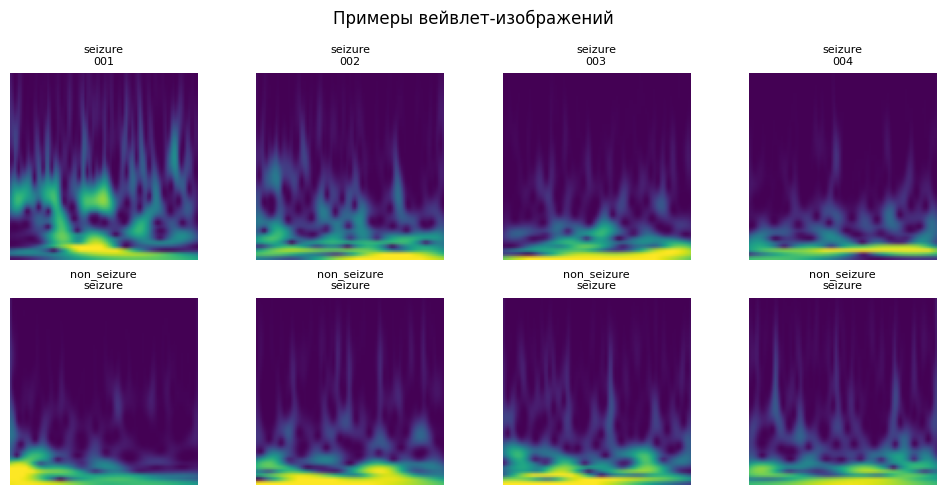

In [9]:
# Визуальная проверка нескольких полученных изображений
sample_files = sorted(list(SEIZURE_DIR.glob("*.png")))[:4] + sorted(list(NON_SEIZURE_DIR.glob("*.png")))[:4]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, p in zip(axes.ravel(), sample_files):
    ax.imshow(Image.open(p))
    ax.set_title(p.parent.name + "\n" + p.name.split("_")[1], fontsize=8)
    ax.axis("off")
plt.suptitle("Примеры вейвлет-изображений")
plt.tight_layout()
plt.savefig(FIG_DIR / "wavelet_examples.png", dpi=160)
plt.show()


In [10]:
# Подготовка данных для CNN
all_paths = sorted(list(SEIZURE_DIR.glob("*.png")) + list(NON_SEIZURE_DIR.glob("*.png")))
y = np.array([1 if p.parent.name == "seizure" else 0 for p in all_paths], dtype=np.int64)

X_list = []
for p in all_paths:
    arr = np.asarray(Image.open(p).convert("RGB").resize(IMAGE_SIZE), dtype=np.float32) / 255.0
    X_list.append(np.transpose(arr, (2, 0, 1)))
X = np.stack(X_list).astype(np.float32)

idx = np.arange(len(X))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

X_train = torch.tensor(X[train_idx], dtype=torch.float32)
y_train = torch.tensor(y[train_idx], dtype=torch.long)
X_test = torch.tensor(X[test_idx], dtype=torch.float32)
y_test = torch.tensor(y[test_idx], dtype=torch.long)

print("train:", X_train.shape, "test:", X_test.shape)


train: torch.Size([80, 3, 96, 96]) test: torch.Size([20, 3, 96, 96])


In [11]:
# Свёрточная нейронная сеть
class MediumEEGCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten()
        )
        self.classifier = nn.Linear(64, 2)

    def forward(self, x):
        return self.classifier(self.features(x))

model = MediumEEGCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

history = []
batch_size = 16

for epoch in range(1, 11):
    model.train()
    perm = torch.randperm(len(X_train))
    loss_sum, correct, total = 0.0, 0, 0

    for s in range(0, len(X_train), batch_size):
        b = perm[s:s+batch_size]
        xb, yb = X_train[b], y_train[b]

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test)
        test_loss = criterion(test_logits, y_test).item()
        test_pred = test_logits.argmax(1)
        test_acc = (test_pred == y_test).float().mean().item()

    history.append({
        "epoch": epoch,
        "train_loss": loss_sum / total,
        "train_acc": correct / total,
        "test_loss": test_loss,
        "test_acc": test_acc
    })

history_df = pd.DataFrame(history)
history_df.to_csv(META_DIR / "training_history.csv", index=False)
history_df


,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.597842,0.6250,0.684736,0.65
1,2,0.526382,0.7000,0.669858,0.65
2,3,0.520624,0.7250,0.651918,0.70
3,4,0.538252,0.6875,0.637586,0.65
4,5,0.530752,0.7375,0.626686,0.65
5,6,0.512526,0.7125,0.620868,0.65
6,7,0.511429,0.7375,0.612714,0.70
7,8,0.519041,0.7625,0.603223,0.65
8,9,0.517841,0.7500,0.594941,0.55
9,10,0.512122,0.7500,0.579304,0.55


In [12]:
# Проверка модели, матрица ошибок, сохранение модели
y_true = y_test.numpy()
y_pred = test_pred.numpy()

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("Accuracy:", acc)
print("Confusion matrix:")
print(cm)
print(classification_report(y_true, y_pred, target_names=["non_seizure", "seizure"], zero_division=0))

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": ["non_seizure", "seizure"],
    "image_size": IMAGE_SIZE,
    "channel": CHANNEL,
    "sfreq": sfreq,
    "segment_duration_s": SEGMENT_DURATION,
    "seizure_interval_s": [SEIZURE_START, SEIZURE_END],
    "test_accuracy": float(acc),
    "architecture": "MediumEEGCNN"
}, MODEL_DIR / "cnn_chb08_05_wavelet.pt")

with open(MODEL_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(y_true, y_pred, target_names=["non_seizure", "seizure"], zero_division=0))

print("Модель сохранена:", MODEL_DIR / "cnn_chb08_05_wavelet.pt")


Accuracy: 0.55
Confusion matrix:
[[4 6]
 [3 7]]
              precision    recall  f1-score   support

 non_seizure       0.57      0.40      0.47        10
     seizure       0.54      0.70      0.61        10

    accuracy                           0.55        20
   macro avg       0.55      0.55      0.54        20
weighted avg       0.55      0.55      0.54        20

Модель сохранена: chb08_05_solution\models\cnn_chb08_05_wavelet.pt


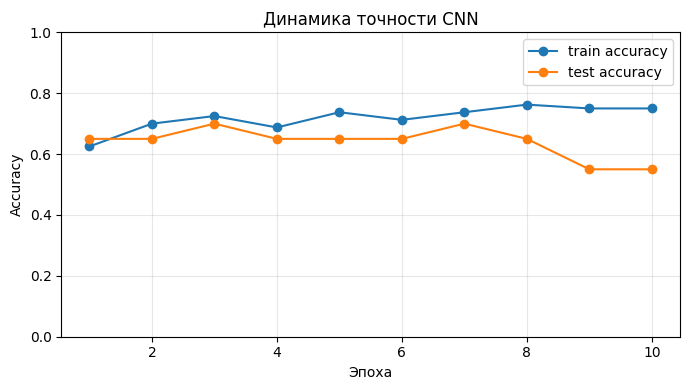

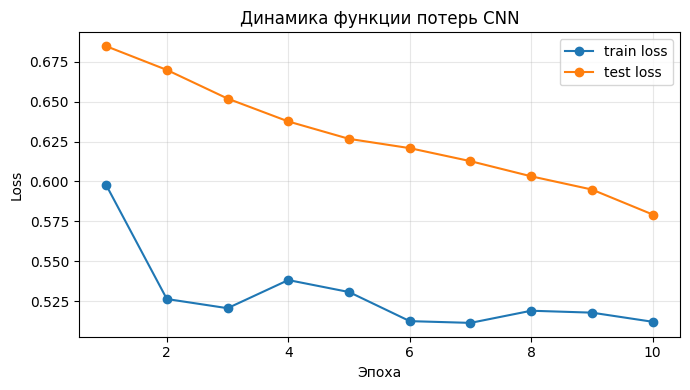

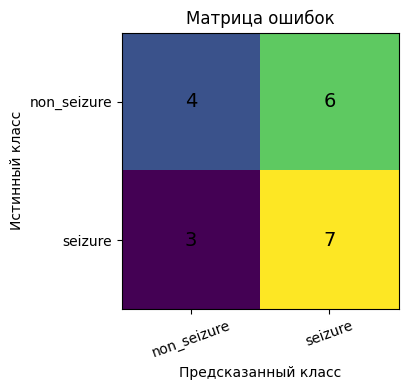

In [13]:
# Построение графиков обучения и матрицы ошибок
plt.figure(figsize=(7,4))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train accuracy")
plt.plot(history_df["epoch"], history_df["test_acc"], marker="o", label="test accuracy")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Динамика точности CNN")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "training_accuracy.png", dpi=160)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
plt.plot(history_df["epoch"], history_df["test_loss"], marker="o", label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Динамика функции потерь CNN")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "training_loss.png", dpi=160)
plt.show()

plt.figure(figsize=(4.5,4))
plt.imshow(cm)
plt.title("Матрица ошибок")
plt.xticks([0,1], ["non_seizure", "seizure"], rotation=20)
plt.yticks([0,1], ["non_seizure", "seizure"])
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=160)
plt.show()


In [14]:
# Финальная проверка структуры папок
verification = {
    "seizure_png": len(list(SEIZURE_DIR.glob("*.png"))),
    "non_seizure_png": len(list(NON_SEIZURE_DIR.glob("*.png"))),
    "total_png": len(list(DATASET_DIR.glob("*/*.png"))),
    "model_exists": (MODEL_DIR / "cnn_chb08_05_wavelet.pt").exists(),
    "figures": [p.name for p in FIG_DIR.glob("*.png")]
}
with open(PROJECT_DIR / "verification.json", "w", encoding="utf-8") as f:
    json.dump(verification, f, ensure_ascii=False, indent=2)

verification


{'seizure_png': 50,
 'non_seizure_png': 50,
 'total_png': 100,
 'model_exists': True,
 'figures': ['confusion_matrix.png',
  'seizure_timeline.png',
  'signal_examples.png',
  'training_accuracy.png',
  'training_loss.png',
  'wavelet_examples.png']}